## Model to be analysed

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
from physics.lump_functions import *
import matplotlib.pyplot as plt
import time

### Util functions

In [95]:
def sigmav_DD_BoschHale(ion_temp_profile):
    r"""Deuterium-Deuterium reaction.

    Calculate :math:`\langle \sigma v \rangle` product for a given characteristic ion energy using Bosch Hale method.

    Function tested on available data at [1, 2, 5, 10, 20, 50, 100] keV.
    Maximum error = 3.8% within range 5-50 keV and increases significantly outside of [5, 50] keV.

    Uses DD cross section formulation from :cite:`bosch_improved_1992`.

    Other form in :cite:`langenbrunner_analytic_2017`.

    Args:
        ion_temp_profile: ion temperature profile [keV]

    Returns:
        :math:`\langle \sigma v \rangle` tuple (total, D(d,p)T, D(d,n)3He) in cm^3/s.
    """
    if hasattr(ion_temp_profile, "magnitude"):
        ion_temp_profile = ion_temp_profile.magnitude
    # For D(d,n)3He
    cBH_1 = [((31.3970**2) / 4.0) ** (1.0 / 3.0), 5.65718e-12, 3.41e-03, 1.99e-03, 0, 1.05e-05, 0, 0]  # 3.72e-16,

    mc2_1 = 937814.0

    # For D(d,p)T
    cBH_2 = [((31.3970**2) / 4.0) ** (1.0 / 3.0), 5.43360e-12, 5.86e-03, 7.68e-03, 0, -2.96e-06, 0, 0]  # 3.57e-16,

    mc2_2 = 937814.0

    thetaBH_1 = ion_temp_profile / (
        1
        - (
            (cBH_1[2] * ion_temp_profile + cBH_1[4] * ion_temp_profile**2 + cBH_1[6] * ion_temp_profile**3)
            / (1 + cBH_1[3] * ion_temp_profile + cBH_1[5] * ion_temp_profile**2 + cBH_1[7] * ion_temp_profile**3)
        )
    )

    thetaBH_2 = ion_temp_profile / (
        1
        - (
            (cBH_2[2] * ion_temp_profile + cBH_2[4] * ion_temp_profile**2 + cBH_2[6] * ion_temp_profile**3)
            / (1 + cBH_2[3] * ion_temp_profile + cBH_2[5] * ion_temp_profile**2 + cBH_2[7] * ion_temp_profile**3)
        )
    )

    etaBH_1: float = cBH_1[0] / (thetaBH_1 ** (1.0 / 3.0))
    etaBH_2: float = cBH_2[0] / (thetaBH_2 ** (1.0 / 3.0))

    sigmav_1 = cBH_1[1] * thetaBH_1 * np.sqrt(etaBH_1 / (mc2_1 * (ion_temp_profile**3.0))) * np.exp(-3.0 * etaBH_1)
    sigmav_2 = cBH_2[1] * thetaBH_2 * np.sqrt(etaBH_2 / (mc2_2 * (ion_temp_profile**3.0))) * np.exp(-3.0 * etaBH_2)
    sigmav_tot = sigmav_1 + sigmav_2

    cm3tom3_per_sec = 1e-6

    sigmav_1 = sigmav_1 * cm3tom3_per_sec  # Reactivity for D(d,p)T reactions [m^3/s]
    sigmav_2 = sigmav_2 * cm3tom3_per_sec  # Reactivity for D(d,n)3He reactions [m^3/s]
    sigmav_tot = sigmav_tot * cm3tom3_per_sec  # Reactivity for DD reactions [m^3/s]
    
    return sigmav_tot, sigmav_1, sigmav_2  # [m^3/s]

def sigmav_DT_BoschHale(ion_temp_profile):
    r"""Deuterium-Tritium reaction.

    Calculate :math:`\langle \sigma v \rangle` product for a given characteristic ion energy using Bosch Hale method.

    :func:`sigmav_DT_BoschHale` is more accurate than :func:`sigmav_DT` for ion_temp_profile > ~48.45 keV (estimate based on
    linear interp between errors found at available datapoints).
    Maximum error = 1.4% within range 50-1000 keV from available NRL data.

    Formulation from :cite:`bosch_improved_1992`

    Args:
        ion_temp_profile: ion temperature profile [keV]

    Returns:
        :math:`\langle \sigma v \rangle` in cm^3/s.

    """
    if hasattr(ion_temp_profile, "magnitude"):
        ion_temp_profile = ion_temp_profile.magnitude
    # Bosch Hale coefficients for DT reaction
    C = [0.0, 1.173e-9, 1.514e-2, 7.519e-2, 4.606e-3, 1.35e-2, -1.068e-4, 1.366e-5]
    B_G = 34.3827
    mr_c2 = 1124656

    theta = ion_temp_profile / (
        1
        - (ion_temp_profile * (C[2] + ion_temp_profile * (C[4] + ion_temp_profile * C[6])))
        / (1 + ion_temp_profile * (C[3] + ion_temp_profile * (C[5] + ion_temp_profile * C[7])))
    )
    eta = (B_G**2 / (4 * theta)) ** (1 / 3)
    sigmav = C[1] * theta * np.sqrt(eta / (mr_c2 * ion_temp_profile**3)) * np.exp(-3 * eta)
    cm3tom3_per_sec = 1e-6
    sigmav = sigmav * cm3tom3_per_sec  # Reactivity for DT reactions [m^3/s]
    return sigmav  # type: ignore[no-any-return] # [m^3/s]

def sigmav_DHe3_BoschHale(ion_temp_profile):
    r"""Deuterium-Helium-3 reaction.

    Calculate :math:`\langle \sigma v \rangle` for a given characteristic ion energy.

    Function tested on available data at [1, 2, 5, 10, 20, 50, 100] keV.
    Maximum error = 8.4% within range 2-100 keV and should not be used outside range [2, 100] keV.

    Uses DD cross section formulation :cite:`bosch_improved_1992`.

    Args:
        ion_temp_profile: ion temperature profile [keV]

    Returns:
        :math:`\langle \sigma v \rangle` in m^3/s.
    """
        
    # For He3(d,p)4He
    cBH_1 = [
        ((68.7508**2) / 4.0) ** (1.0 / 3.0),
        5.51036e-10,  # 3.72e-16,
        6.41918e-03,
        -2.02896e-03,
        -1.91080e-05,
        1.35776e-04,
        0,
        0,
    ]

    mc2_1 = 1124572.0

    thetaBH_1 = ion_temp_profile / (
        1
        - (
            (cBH_1[2] * ion_temp_profile + cBH_1[4] * ion_temp_profile**2 + cBH_1[6] * ion_temp_profile**3)
            / (1 + cBH_1[3] * ion_temp_profile + cBH_1[5] * ion_temp_profile**2 + cBH_1[7] * ion_temp_profile**3.0)
        )
    )

    etaBH_1: float = cBH_1[0] / (thetaBH_1 ** (1.0 / 3.0))

    sigmav= cBH_1[1] * thetaBH_1 * np.sqrt(etaBH_1 / (mc2_1 * (ion_temp_profile**3.0))) * np.exp(-3.0 * etaBH_1)

    return sigmav*1e-6  # [m^3/s]

### Solve the model for 1 sample point

In [89]:
def solve_for_sample(sample):
    # Unpack sample parameters
    Vp, temp_kev, ntot, tau_p_T, P_aux, P_aux_DT_eq, TBRDT, TBRDD, tau_ifc, tau_ofc, eta_th, C_f, c_dollar_per_J = sample
    # if ntot <= 0 or temp_kev <= 0 or TBRDT <= 0 or TBRDD <= 0:
    #     return {'success': False, 'error': 'Unphysical parameter'}
    # Vp = 150
    # ntot = 1.7e20  # total density
    # # tau_p_T = 0.1
    # eta_th = 0.3
    # P_aux = 100 # MW

    sigmavDT = sigmav_DT_BoschHale(temp_kev)
    sigmavDDn = sigmav_DD_BoschHale(temp_kev)[2]
    sigmavDDp = sigmav_DD_BoschHale(temp_kev)[1]

    tritium_mass = 3.016049268e-3 / 6.022e23  # kg per tritium atom

    # tau_ofc = 3600*24 # hours
    # tau_ifc = 3600*12 # hours

    # C_f = 0.7 # capacity factor [-]
    # c_dollar_per_J = 5e-8

    MeV_to_J = 1.6022e-13

    # Energy released by fusion reactions
    E_DDp = 4.03*MeV_to_J # [J] energy released by DDp reactions
    E_DDn = 3.46*MeV_to_J # [J] energy released by DDn reactions
    E_DT = 17.6*MeV_to_J # [J] energy released by DT reactions

    lambda_T = 1.78e-9

    injection_rate_max = (ntot/2/tau_p_T*Vp + 0.25*ntot**2*sigmavDT*Vp - 0.25/2*ntot**2*sigmavDDp*Vp)

    def tritium_inventory_odes1(t, y):
        N_ofc, N_ifc, N_st, nT = y
        if N_st < 0.001/tritium_mass:
            injection_rate = 0.0
        else:
            injection_rate = min((N_ifc/tau_ifc - lambda_T*N_st), injection_rate_max)
        # print(injection_rate)
        nD = (ntot - nT)
        dN_ofc_dt = TBRDT*nD*nT*sigmavDT*Vp + TBRDD*0.5*nD**2*sigmavDDn*Vp - N_ofc / tau_ofc - N_ofc*lambda_T
        dN_ifc_dt = N_ofc / tau_ofc - N_ifc / tau_ifc  - lambda_T * N_ifc + nT / tau_p_T * Vp
        dN_stor_dt = N_ifc / tau_ifc - lambda_T * N_st - max(injection_rate,0)
        dnT_dt = injection_rate/Vp + 0.5*nD**2*sigmavDDp - nT/tau_p_T - nD*nT*sigmavDT
        return [dN_ofc_dt, dN_ifc_dt, dN_stor_dt, dnT_dt]

    y0 = [0.0, 0.0, 0.0, 0.0] 
    years_to_seconds = 365 * 24 * 3600
    t_span = (0, 10*years_to_seconds)
    vector_length = 100
    t_eval = np.linspace(*t_span, vector_length)

    def DT_reached(t, y):
        return y[3] - (0.5 * ntot)
    def NEGATIVE(t, y):
        return min(y[0]+100, y[1]+100, y[2]+100, y[3]+100)
    DT_reached.terminal = True
    NEGATIVE.terminal = True

    try:
        sol = solve_ivp(tritium_inventory_odes1, t_span, y0, method='BDF', events=[DT_reached, NEGATIVE], dense_output=False)
        if sol.t_events[0].size > 0:
            startup_time = sol.t_events[0][0]
        else:
            return {'success': False, 'error': 'DT target not reached within simulation timeframe'}
        t_startup = sol.t_events[0][0]  # DT reached event
        y_event = sol.y_events[0][0]    # Exact state at event time
        t_with_event = np.append(sol.t, t_startup)
        y0_with_event = np.append(sol.y[0], y_event[0])
        y1_with_event = np.append(sol.y[1], y_event[1])
        y2_with_event = np.append(sol.y[2], y_event[2])
        y3_with_event = np.append(sol.y[3], y_event[3])
        
        # Sort by time (event time should be at end, but be safe)
        sort_idx = np.argsort(t_with_event)
        t_sorted = t_with_event[sort_idx]
        y0_sorted = y0_with_event[sort_idx]
        y1_sorted = y1_with_event[sort_idx]
        y2_sorted = y2_with_event[sort_idx]
        y3_sorted = y3_with_event[sort_idx]
        
        # Create uniform time grid from 0 to t_startup with vector_length points
        t_interp = np.linspace(0, t_startup, vector_length)
        
        # Interpolate solution onto the new time grid using augmented data
        # This ensures we have exactly vector_length points from 0 to t_startup
        # with correct final values at t_startup
        N_ofc = np.interp(t_interp, t_sorted, y0_sorted)
        N_ifc = np.interp(t_interp, t_sorted, y1_sorted)
        N_st = np.interp(t_interp, t_sorted, y2_sorted)
        n_T = np.interp(t_interp, t_sorted, y3_sorted)
        n_D = ntot - n_T  # Deuterium density

        # Pre-compute common terms to avoid redundant calculations
        n_D_squared = n_D**2  # Compute once, use multiple times
        n_D_n_T = n_D * n_T      # Compute once for DT reactions
        V_E_DDn = Vp * E_DDn  # Pre-compute scalar products
        V_E_DDp = Vp * E_DDp
        V_E_DT = Vp * E_DT

        # Calculate fusion powers (all in Watts)
        P_DDn = n_D_squared * sigmavDDn / 2 * V_E_DDn
        P_DDp = n_D_squared * sigmavDDp / 2 * V_E_DDp
        P_DT = n_D_n_T * sigmavDT * V_E_DT
        P_DT_eq = ntot/2 * ntot/2 * sigmavDT * V_E_DT  # Equivalent if always DT
    
        # Total fusion energies by integration (use interpolated time grid)
        E_fusion_DDn = np.trapezoid(P_DDn, t_interp)
        E_fusion_DDp = np.trapezoid(P_DDp, t_interp)
        E_fusion_DT = np.trapezoid(P_DT, t_interp)
        E_fusion_total_DD = E_fusion_DDn + E_fusion_DDp + E_fusion_DT
        E_fusion_DT_eq = P_DT_eq * t_startup  # Constant power * time
        
        # Pre-compute auxiliary power energy (scalar operations)
        E_aux_DD = P_aux * t_startup
        E_aux_DT_eq = P_aux_DT_eq * t_startup

        # Net electrical energies (with thermal efficiency and plant availability)
        E_e_net_DD = C_f * (eta_th * (E_fusion_total_DD) - E_aux_DD)
        E_e_net_DT_eq = C_f * (eta_th * (E_fusion_DT_eq) - E_aux_DT_eq)
        
        # Q factors based on total energy
        Q_DD = E_fusion_total_DD / E_aux_DD if E_aux_DD > 0 else np.inf
        Q_DT_eq = E_fusion_DT_eq / E_aux_DT_eq if E_aux_DT_eq > 0 else np.inf
        
        # # Average powers for reference (divide total energy by time)
        # P_fusion_DD_avg = E_fusion_total_DD / t_startup
        # P_e_net_DD_avg = E_e_net_DD / t_startup
        # P_e_net_DT_eq_avg = E_e_net_DT_eq / t_startup 

        E_lost = E_e_net_DT_eq - E_e_net_DD
        unrealized_profits = E_lost * c_dollar_per_J # Cost in dollars (NB Cost is in 1/J)
        if not (np.isfinite(startup_time) and np.isfinite(unrealized_profits)):
            return {'success': False, 'error': 'Non-finite output metrics calculated'}
        return {'success': sol.success, 'injection_rate_max': injection_rate_max, 'solution': sol, 'n_T': n_T, 'startup_time': startup_time, "unrealized_gain": unrealized_profits, "sigmavDT": sigmavDT, "sigmavDDp": sigmavDDp, "sigmavDDn": sigmavDDn, "sample": sample}
    except Exception as e:
        return {'success': False, 'error': str(e)}

In [90]:
parameter_ranges = {
    "v_plasma": [1.0e2, 20e2],
    "T_i": [1.0e1, 2e1],
    "n_tot": [0.75e20, 2.0e20],
    "tau_p_T": [1.0e-1, 50e-1],
    "P_aux": [20e6, 80e6],
    "P_aux_DT_eq": [20e6, 80e6],
    "TBR_DT": [1.05e0, 1.3e0],
    "TBR_DDn": [0.5e0, 1.0e0],
    "tau_ifc": [3600*1.0, 3600*12.0],
    "tau_ofc": [3600*6.0, 3600*36.0],
    "eta_th": [0.3, 0.4],
    "capacity_factor": [0.5, 0.9],
    "cost_of_electricity": [2.778e-8, 1.111e-7]
}


## Solve elementary effects - T seeded

Running Elementary Effects analysis with 200 trajectories
This will require approximately 2800 model evaluations
Normalization: Enabled
Trajectory 1/200
Perturbed point evaluation failed: DT target not reached within simulation timeframe
Trajectory 2/200
Perturbed point evaluation failed: DT target not reached within simulation timeframe
Trajectory 3/200
Perturbed point evaluation failed: DT target not reached within simulation timeframe
Perturbed point evaluation failed: DT target not reached within simulation timeframe
Perturbed point evaluation failed: DT target not reached within simulation timeframe
Perturbed point evaluation failed: DT target not reached within simulation timeframe
Trajectory 4/200
Perturbed point evaluation failed: DT target not reached within simulation timeframe
Trajectory 5/200
Perturbed point evaluation failed: DT target not reached within simulation timeframe
Trajectory 6/200
Perturbed point evaluation failed: DT target not reached within simulation timefra

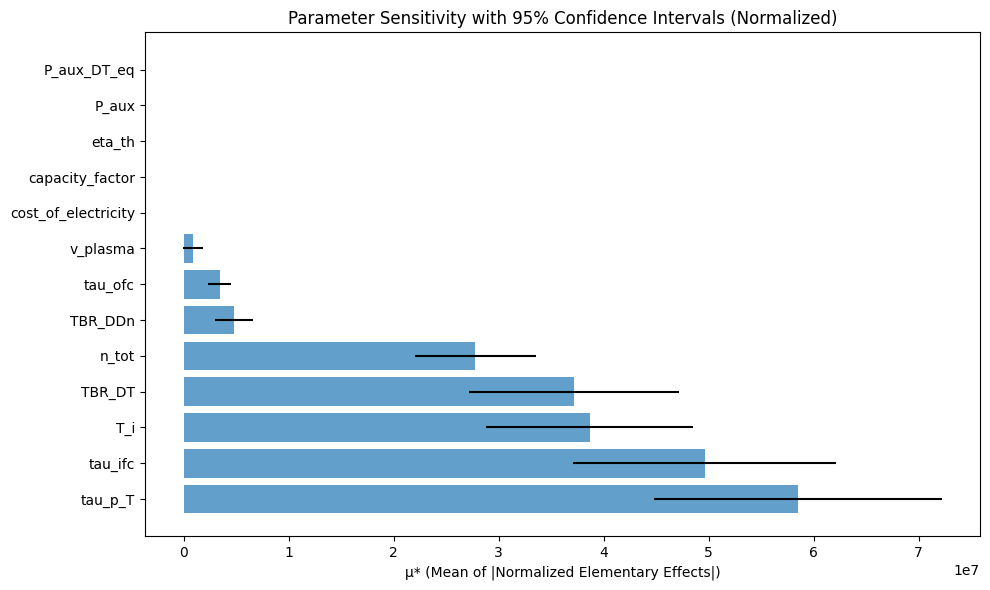

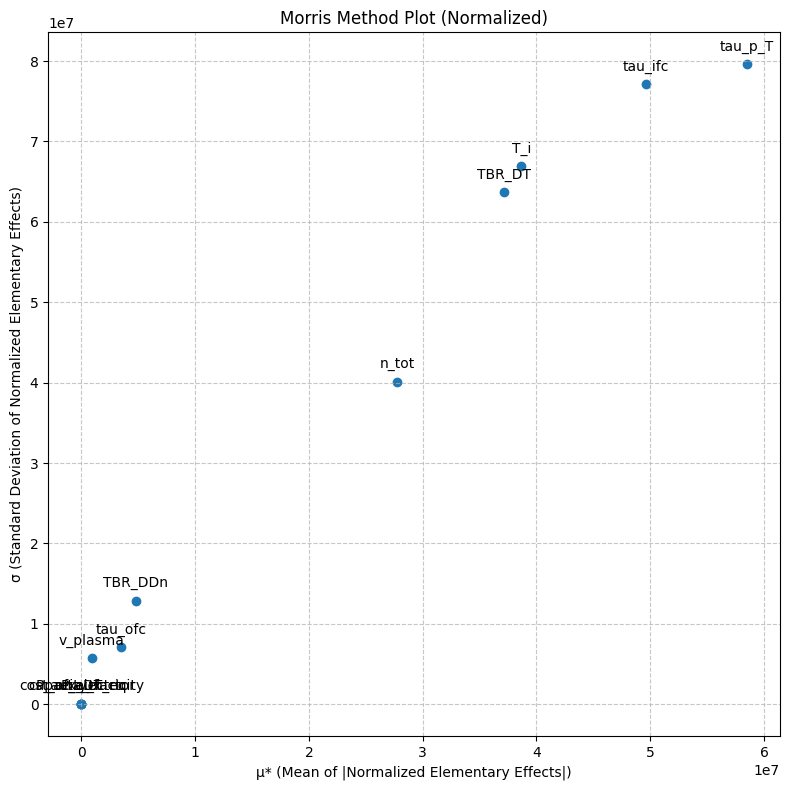


Parameter Sensitivity Ranking:
----------------------------------------
1. tau_p_T: 5.848632e+07 ± 1.373524e+07 (95% CI, n=129)
2. tau_ifc: 4.960664e+07 ± 1.250446e+07 (95% CI, n=146)
3. T_i: 3.867948e+07 ± 9.854254e+06 (95% CI, n=177)
4. TBR_DT: 3.714299e+07 ± 9.990348e+06 (95% CI, n=156)
5. n_tot: 2.775965e+07 ± 5.752503e+06 (95% CI, n=187)
6. TBR_DDn: 4.789818e+06 ± 1.828389e+06 (95% CI, n=189)
7. tau_ofc: 3.448286e+06 ± 1.105606e+06 (95% CI, n=157)
8. v_plasma: 8.868901e+05 ± 9.639501e+05 (95% CI, n=135)
9. cost_of_electricity: 0.000000e+00 ± 0.000000e+00 (95% CI, n=194)
10. capacity_factor: 0.000000e+00 ± 0.000000e+00 (95% CI, n=194)
11. eta_th: 0.000000e+00 ± 0.000000e+00 (95% CI, n=194)
12. P_aux: 0.000000e+00 ± 0.000000e+00 (95% CI, n=194)
13. P_aux_DT_eq: 0.000000e+00 ± 0.000000e+00 (95% CI, n=194)
Running Elementary Effects analysis with 200 trajectories
This will require approximately 2800 model evaluations
Normalization: Enabled
Trajectory 1/200
Perturbed point evaluation 

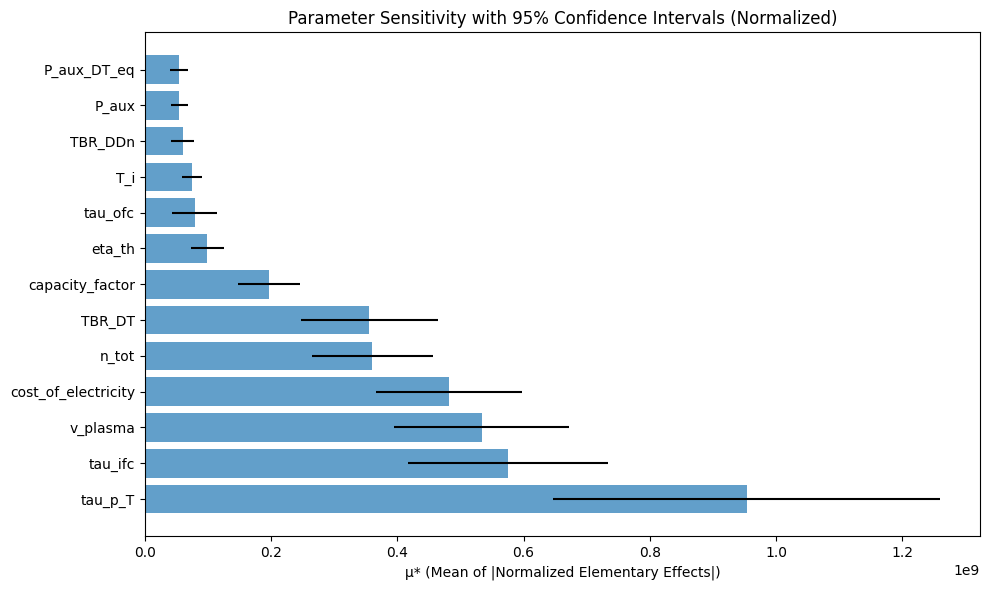

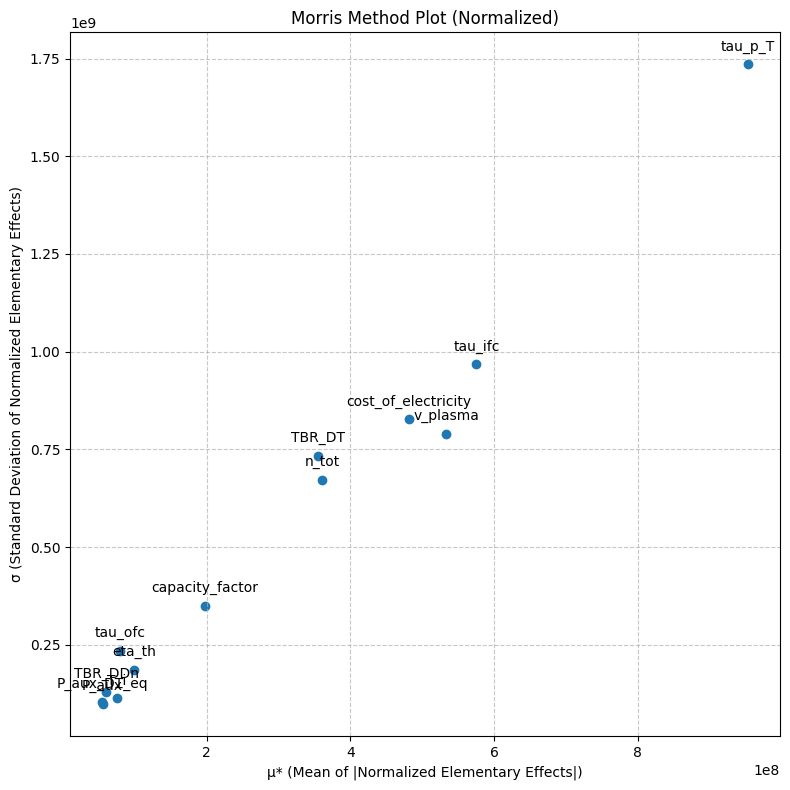


Parameter Sensitivity Ranking:
----------------------------------------
1. tau_p_T: 9.534807e+08 ± 3.066523e+08 (95% CI, n=123)
2. tau_ifc: 5.754574e+08 ± 1.580644e+08 (95% CI, n=144)
3. v_plasma: 5.334446e+08 ± 1.384999e+08 (95% CI, n=125)
4. cost_of_electricity: 4.813485e+08 ± 1.155098e+08 (95% CI, n=197)
5. n_tot: 3.603542e+08 ± 9.598331e+07 (95% CI, n=188)
6. TBR_DT: 3.552214e+08 ± 1.084700e+08 (95% CI, n=176)
7. capacity_factor: 1.968244e+08 ± 4.873139e+07 (95% CI, n=197)
8. eta_th: 9.897368e+07 ± 2.587302e+07 (95% CI, n=197)
9. tau_ofc: 7.867557e+07 ± 3.576898e+07 (95% CI, n=166)
10. T_i: 7.487683e+07 ± 1.637902e+07 (95% CI, n=184)
11. TBR_DDn: 6.015747e+07 ± 1.838631e+07 (95% CI, n=193)
12. P_aux: 5.464402e+07 ± 1.372060e+07 (95% CI, n=197)
13. P_aux_DT_eq: 5.432420e+07 ± 1.469170e+07 (95% CI, n=197)


{'startup_time': {'mu': {'v_plasma': np.float64(125023.02508611171),
   'T_i': np.float64(-38679480.37482534),
   'n_tot': np.float64(-27759652.005059287),
   'tau_p_T': np.float64(-58486321.89616043),
   'P_aux': np.float64(0.0),
   'P_aux_DT_eq': np.float64(0.0),
   'TBR_DT': np.float64(-37142994.49612057),
   'TBR_DDn': np.float64(-2419894.3196703917),
   'tau_ifc': np.float64(49606643.637562424),
   'tau_ofc': np.float64(2301425.721816397),
   'eta_th': np.float64(0.0),
   'capacity_factor': np.float64(0.0),
   'cost_of_electricity': np.float64(0.0)},
  'mu_star': {'v_plasma': np.float64(886890.061732653),
   'T_i': np.float64(38679480.37482534),
   'n_tot': np.float64(27759652.005059287),
   'tau_p_T': np.float64(58486321.89616043),
   'P_aux': np.float64(0.0),
   'P_aux_DT_eq': np.float64(0.0),
   'TBR_DT': np.float64(37142994.49612057),
   'TBR_DDn': np.float64(4789818.211491629),
   'tau_ifc': np.float64(49606643.637562424),
   'tau_ofc': np.float64(3448286.4798564455),
   'eta

In [ ]:
def run_elementary_effects(solve_for_sample, parameter_ranges, num_trajectories=10, 
                           output_metric='startup_time', normalize=True):
    """
    Run Elementary Effects (Morris) sensitivity analysis on the model.
    
    Parameters:
    -----------
    solve_for_sample : function
        Model function that takes a parameter vector and returns results
    parameter_ranges : dict
        Dictionary with parameter names as keys and [min, max] ranges as values
    num_trajectories : int
        Number of trajectories to sample
    output_metric : str
        Name of the output metric to analyze in the model results
    normalize : bool
        Whether to normalize elementary effects by parameter ranges
    
    Returns:
    --------
    dict
        Dictionary with sensitivity metrics and raw data
    """
    param_names = list(parameter_ranges.keys())
    num_params = len(param_names)
    
    # Store elementary effects for each parameter
    ee_values = {name: [] for name in param_names}
    
    # Track progress
    total_runs = num_trajectories * (num_params + 1)
    print(f"Running Elementary Effects analysis with {num_trajectories} trajectories")
    print(f"This will require approximately {total_runs} model evaluations")
    print(f"Normalization: {'Enabled' if normalize else 'Disabled'}")
    
    start_time = time.time()
    
    # For each trajectory
    for traj in range(num_trajectories):
        print(f"Trajectory {traj+1}/{num_trajectories}")
        
        # Generate random base point
        base_point = []
        for name in param_names:
            min_val, max_val = parameter_ranges[name]
            value = min_val + np.random.random() * (max_val - min_val)
            base_point.append(value)
        
        # Evaluate base point
        base_result = solve_for_sample(base_point)
        if not base_result['success']:
            print(f"Base point evaluation failed: {base_result.get('error', 'Unknown error')}")
            continue
        
        base_output = base_result[output_metric]
        if not np.isfinite(base_output):
            print(f"Base point has non-finite {output_metric}: {base_output}")
            continue
        
        # Create random permutation of parameters
        param_order = np.random.permutation(num_params)
        
        # Current position in parameter space
        current_point = base_point.copy()
        current_output = base_output
        
        # For each parameter in the random order
        for param_idx in param_order:
            param_name = param_names[param_idx]
            min_val, max_val = parameter_ranges[param_name]
            param_range = max_val - min_val
            
            # Create perturbed point
            perturbed_point = current_point.copy()
            
            # Calculate perturbation (using delta = 2/3 of parameter range)
            delta = 2/3 * param_range
            
            # Apply perturbation, ensuring we stay within bounds
            if current_point[param_idx] + delta <= max_val:
                perturbed_point[param_idx] = current_point[param_idx] + delta
            else:
                perturbed_point[param_idx] = current_point[param_idx] - delta
            
            # Evaluate perturbed point
            perturbed_result = solve_for_sample(perturbed_point)
            if not perturbed_result['success']:
                print(f"Perturbed point evaluation failed: {perturbed_result.get('error', 'Unknown error')}")
                continue
                
            perturbed_output = perturbed_result[output_metric]
            if not np.isfinite(perturbed_output):
                print(f"Perturbed point has non-finite {output_metric}: {perturbed_output}")
                continue
            
            # Calculate elementary effect
            parameter_change = perturbed_point[param_idx] - current_point[param_idx]
            if parameter_change != 0:  # Avoid division by zero
                ee = (perturbed_output - current_output) / parameter_change
                
                # Apply normalization if requested
                if normalize:
                    # Normalize by parameter range to make effects comparable across parameters
                    ee = ee * param_range
                
                if np.isfinite(ee):  # This checks for both non-Inf and non-NaN
                    ee_values[param_name].append(ee)
                else:
                    print(f"Warning: Non-finite elementary effect for {param_name}: {ee}")
            
            # Move to perturbed point for next parameter
            current_point = perturbed_point
            current_output = perturbed_output
    
    # Calculate sensitivity metrics
    results = {
        'mu': {},       # Mean
        'mu_star': {},  # Mean of absolute values (main sensitivity metric)
        'sigma': {},    # Standard deviation (interaction effects)
        'ee_values': ee_values,  # Raw data
        'normalized': normalize   # Track whether results are normalized
    }
    
    for name in param_names:
        effects = np.array(ee_values[name])
        if len(effects) > 0:
            results['mu'][name] = np.mean(effects)
            results['mu_star'][name] = np.mean(np.abs(effects))
            results['sigma'][name] = np.std(effects)
        else:
            print(f"Warning: No valid elementary effects for parameter {name}")
            results['mu'][name] = np.nan
            results['mu_star'][name] = np.nan
            results['sigma'][name] = np.nan
    
    elapsed_time = time.time() - start_time
    print(f"Analysis completed in {elapsed_time:.2f} seconds")
    
    # Plot results
    plot_morris_results(results)
    
    return results

def plot_morris_results(results):
    """Create plots of Morris method results with 95% confidence intervals."""
    # Extract data
    param_names = list(results['mu'].keys())
    mu_star_values = [results['mu_star'][name] for name in param_names]
    sigma_values = [results['sigma'][name] for name in param_names]
    normalized = results.get('normalized', False)
    
    # Calculate standard error and 95% confidence intervals for each parameter
    sem_values = []
    ci95_values = []
    sample_sizes = []
    for name in param_names:
        effects = np.array(results['ee_values'][name])
        sample_sizes.append(len(effects))
        if len(effects) > 0:
            # Standard error = standard deviation / sqrt(sample size)
            sem = results['sigma'][name] / np.sqrt(len(effects))
            sem_values.append(sem)
            # 95% confidence interval = 1.96 * SEM for normal distribution
            ci95 = 1.96 * sem
            ci95_values.append(ci95)
        else:
            sem_values.append(np.nan)
            ci95_values.append(np.nan)
    
    # Check if we have enough valid data to plot
    valid_indices = [i for i, (mu, ci) in enumerate(zip(mu_star_values, ci95_values)) 
                     if np.isfinite(mu) and np.isfinite(ci)]
    
    if len(valid_indices) == 0:
        print("No valid data to plot. All results are NaN or Inf.")
        return
    
    # Filter to only valid data
    valid_names = [param_names[i] for i in valid_indices]
    valid_mu_star = [mu_star_values[i] for i in valid_indices]
    valid_sigma = [sigma_values[i] for i in valid_indices]
    valid_sem = [sem_values[i] for i in valid_indices]
    valid_ci95 = [ci95_values[i] for i in valid_indices]
    valid_sizes = [sample_sizes[i] for i in valid_indices]
    
    # Sort parameters by sensitivity (using only valid data)
    sorted_indices = np.argsort(valid_mu_star)[::-1]
    sorted_names = [valid_names[i] for i in sorted_indices]
    sorted_mu_star = [valid_mu_star[i] for i in sorted_indices]
    sorted_sigma = [valid_sigma[i] for i in sorted_indices]
    sorted_sem = [valid_sem[i] for i in sorted_indices]
    sorted_ci95 = [valid_ci95[i] for i in sorted_indices]
    sorted_sizes = [valid_sizes[i] for i in sorted_indices]
    
    # Create horizontal bar plot with 95% confidence intervals as error bars
    plt.figure(figsize=(10, 6))
    y_pos = np.arange(len(sorted_names))
    plt.barh(y_pos, sorted_mu_star, xerr=sorted_ci95, align='center', alpha=0.7)
    plt.yticks(y_pos, sorted_names)
    
    norm_text = "Normalized " if normalized else ""
    plt.xlabel(f'μ* (Mean of |{norm_text}Elementary Effects|)')
    plt.title(f'Parameter Sensitivity with 95% Confidence Intervals{" (Normalized)" if normalized else ""}')
    plt.tight_layout()
    plt.show()
    
    # Create scatter plot of mu* vs sigma (keep this unchanged)
    plt.figure(figsize=(8, 8))
    plt.scatter(sorted_mu_star, sorted_sigma)
    
    # Add parameter labels
    for i, name in enumerate(sorted_names):
        plt.annotate(name, (sorted_mu_star[i], sorted_sigma[i]), 
                    textcoords="offset points", 
                    xytext=(0,10), 
                    ha='center')
    
    plt.xlabel(f'μ* (Mean of |{norm_text}Elementary Effects|)')
    plt.ylabel(f'σ (Standard Deviation of {norm_text}Elementary Effects)')
    plt.title(f'Morris Method Plot{" (Normalized)" if normalized else ""}')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Print ranking with 95% confidence intervals
    print("\nParameter Sensitivity Ranking:")
    print("-" * 40)
    for i, name in enumerate(sorted_names):
        print(f"{i+1}. {name}: {sorted_mu_star[i]:.6e} ± {sorted_ci95[i]:.6e} (95% CI, n={sorted_sizes[i]})")

# Run the Elementary Effects analysis
def analyze_model_sensitivity(normalize=True):
    # Set number of trajectories - more is better but costs more computationally
    num_trajectories = 40
    
    # Run the analysis for startup time
    results_startup = run_elementary_effects(
        solve_for_sample=solve_for_sample,
        parameter_ranges=parameter_ranges,
        num_trajectories=num_trajectories,
        output_metric='startup_time',
        normalize=normalize
    )
    
    # Analyze effect on unrealized gain (profit loss)
    results_gain = run_elementary_effects(
        solve_for_sample=solve_for_sample,
        parameter_ranges=parameter_ranges,
        num_trajectories=num_trajectories,
        output_metric='unrealized_gain',
        normalize=normalize
    )
    
    return {
        'startup_time': results_startup,
        'unrealized_gain': results_gain
    }

# Execute the analysis with normalization
analyze_model_sensitivity(normalize=True)

## Solve elementary effects - lump

In [107]:
def lump_model(sample):
    V_plasma, temp_kev, n_tot, tau_p_T, P_aux, P_aux_DT_eq, TBR_DT, TBR_DDn, I_target, eta_th, capacity_factor, cost_of_electricity = sample

    n_D = n_tot

    sigmav_DT = sigmav_DT_BoschHale(temp_kev)
    sigmav_DD_n = sigmav_DD_BoschHale(temp_kev)[2]
    sigmav_DD_p = sigmav_DD_BoschHale(temp_kev)[1]
    sigmav_DHe3 = sigmav_DHe3_BoschHale(temp_kev)
    tau_p_He3 = 1
    tritium_mass = 3.016049268e-3 / 6.022e23
    lambda_T = 1.78e-9
    MeV_to_J = 1.6022e-13

    # Energy released by fusion reactions
    E_DDp = 4.03*MeV_to_J # [J] energy released by DDp reactions
    E_DDn = 3.46*MeV_to_J # [J] energy released by DDn reactions
    E_DT = 17.6*MeV_to_J # [J] energy released by DT reactions
    E_DHe3 = 18.3*MeV_to_J # [J] energy released by DHe3 reactions
    # --- Startup tritium balance as in parametric_analysis_I_startup.py ---
    # n_T is the steady-state tritium density during startup
    n_T = (0.5 * n_D**2 * sigmav_DD_p) / (n_D * sigmav_DT + 1 / tau_p_T)
    n_He3 = (0.5 * n_D**2 * sigmav_DD_n) / (n_D * sigmav_DHe3 + 1 / tau_p_He3)

    # Total tritium production rate (from all sources)
    Tdot_DDn = TBR_DDn * 0.5 * n_D**2 * sigmav_DD_n * V_plasma
    Tdot_DDp = 0.5 * n_D**2 * sigmav_DD_p * V_plasma
    Tdot_DT = TBR_DT * n_D * n_T * sigmav_DT * V_plasma
    Tdot_tot = Tdot_DDn + Tdot_DDp + Tdot_DT
    # Required tritium inventory (atoms)
    N_ST = I_target / tritium_mass

    # Startup time (tritium inventory build-up) -- use same logic as parametric_analysis_I_startup.py
    ratio = N_ST * lambda_T / Tdot_tot if Tdot_tot > 0 else np.inf
    if ratio >= 1:
        t_startup = np.inf
        return {"success": False, 'startup_time': t_startup}
    else:
        t_startup = - (1/lambda_T) * np.log(1 - (ratio))

        # Power and energy calculations
        Pf_DDp = n_D**2 * sigmav_DD_p * V_plasma * E_DDp
        Pf_DDn = n_D**2 * sigmav_DD_n * V_plasma * E_DDn
        Pf_DD = Pf_DDp + Pf_DDn
        Pf_DD_DT = n_D * n_T * sigmav_DT * V_plasma * E_DT
        Pf_DD_DHe3 = n_D * n_He3 * sigmav_DHe3 * V_plasma * E_DHe3
        Pf_DD_tot = Pf_DD + Pf_DD_DT + Pf_DD_DHe3
        Pf_DT_eq = (n_tot/2)**2 * sigmav_DT * V_plasma * E_DT
        Q_DD = (Pf_DD_tot - P_aux) / P_aux if P_aux > 0 else np.inf
        P_e_net = capacity_factor * (eta_th * (Pf_DD_tot) - P_aux)
        Q_DT_eq = (Pf_DT_eq - P_aux_DT_eq) / P_aux_DT_eq if P_aux_DT_eq > 0 else np.inf
        P_e_net_DT_eq = capacity_factor * (eta_th * (Pf_DT_eq) - P_aux_DT_eq)

        # Energies
        E_e_net_DD = P_e_net * t_startup
        E_e_net_DT_eq = P_e_net_DT_eq * t_startup
        E_lost = E_e_net_DT_eq - E_e_net_DD
        unrealized_profits = E_lost * cost_of_electricity

    return {"success": True, 'startup_time': t_startup, "unrealized_gain": unrealized_profits}

In [93]:
parameter_ranges_lump = {
    "v_plasma": [1.0e2, 20e2],
    "T_i": [1.0e1, 2e1],
    "n_tot": [0.75e20, 2.0e20],
    "tau_p_T": [1.0e-1, 50e-1],
    "P_aux": [20e6, 80e6],
    "P_aux_DT_eq": [20e6, 80e6],
    "TBR_DT": [1.05e0, 1.3e0],
    "TBR_DDn": [0.5e0, 1.0e0],
    "I_target": [0.1, 5.0],
    "eta_th": [0.3, 0.4],
    "capacity_factor": [0.5, 0.9],
    "cost_of_electricity": [2.778e-8, 1.111e-7]
}

Running Elementary Effects analysis with 1000 trajectories
This will require approximately 13000 model evaluations
Normalization: Enabled
Trajectory 1/1000
Trajectory 2/1000
Trajectory 3/1000
Trajectory 4/1000
Perturbed point evaluation failed: Unknown error
Trajectory 5/1000
Perturbed point evaluation failed: Unknown error
Trajectory 6/1000
Perturbed point evaluation failed: Unknown error
Trajectory 7/1000
Trajectory 8/1000
Trajectory 9/1000
Perturbed point evaluation failed: Unknown error
Trajectory 10/1000
Trajectory 11/1000
Perturbed point evaluation failed: Unknown error
Trajectory 12/1000
Trajectory 13/1000
Perturbed point evaluation failed: Unknown error
Trajectory 14/1000
Perturbed point evaluation failed: Unknown error
Trajectory 15/1000
Trajectory 16/1000
Trajectory 17/1000
Trajectory 18/1000
Perturbed point evaluation failed: Unknown error
Perturbed point evaluation failed: Unknown error
Trajectory 19/1000
Perturbed point evaluation failed: Unknown error
Trajectory 20/1000
T

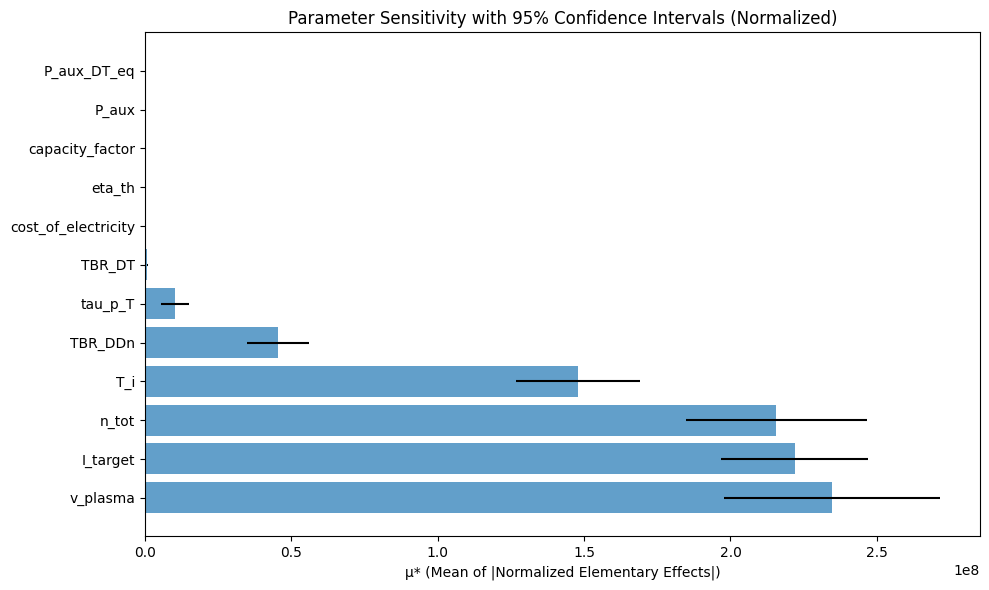

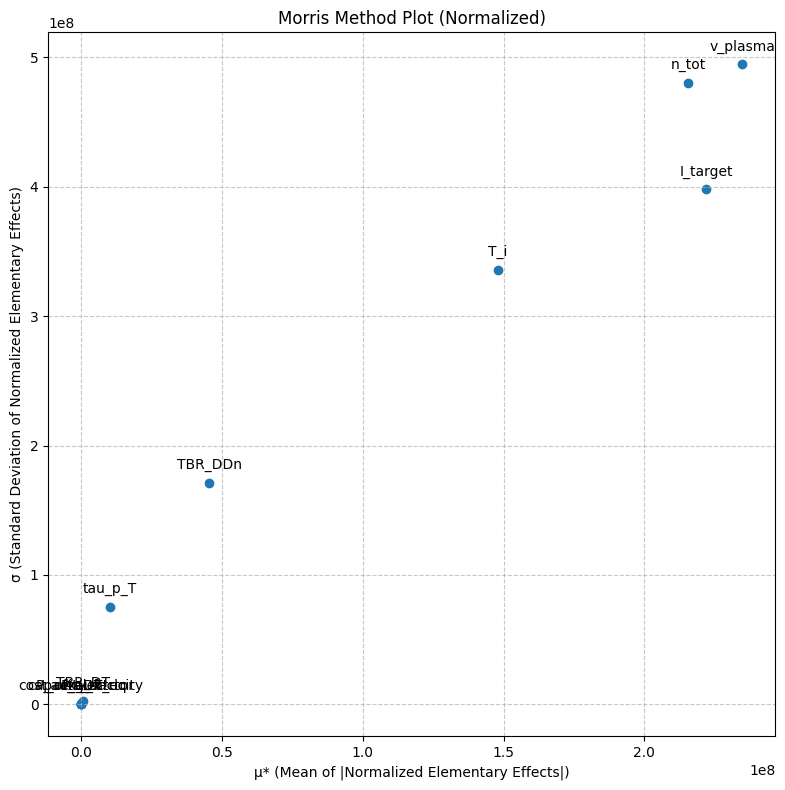


Parameter Sensitivity Ranking:
----------------------------------------
1. v_plasma: 2.347380e+08 ± 3.688540e+07 (95% CI, n=691)
2. I_target: 2.219095e+08 ± 2.521432e+07 (95% CI, n=957)
3. n_tot: 2.155582e+08 ± 3.089245e+07 (95% CI, n=929)
4. T_i: 1.479667e+08 ± 2.129617e+07 (95% CI, n=955)
5. TBR_DDn: 4.543726e+07 ± 1.068939e+07 (95% CI, n=984)
6. tau_p_T: 1.023580e+07 ± 4.671763e+06 (95% CI, n=992)
7. TBR_DT: 7.771937e+05 ± 1.747344e+05 (95% CI, n=994)
8. cost_of_electricity: 0.000000e+00 ± 0.000000e+00 (95% CI, n=994)
9. eta_th: 0.000000e+00 ± 0.000000e+00 (95% CI, n=994)
10. capacity_factor: 0.000000e+00 ± 0.000000e+00 (95% CI, n=994)
11. P_aux: 0.000000e+00 ± 0.000000e+00 (95% CI, n=994)
12. P_aux_DT_eq: 0.000000e+00 ± 0.000000e+00 (95% CI, n=994)
Running Elementary Effects analysis with 1000 trajectories
This will require approximately 13000 model evaluations
Normalization: Enabled
Trajectory 1/1000
Perturbed point evaluation failed: Unknown error
Trajectory 2/1000
Trajectory 3/

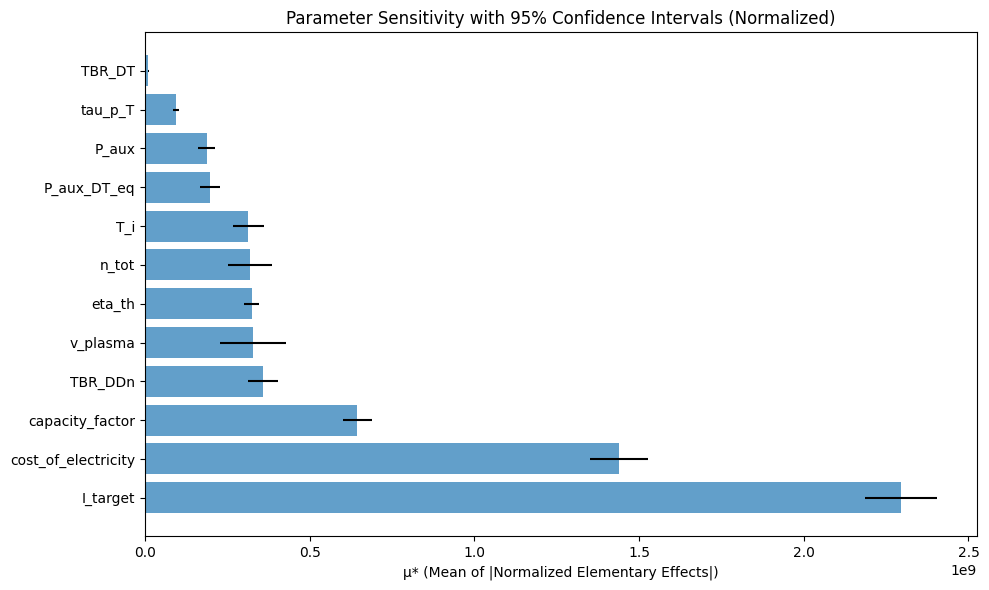

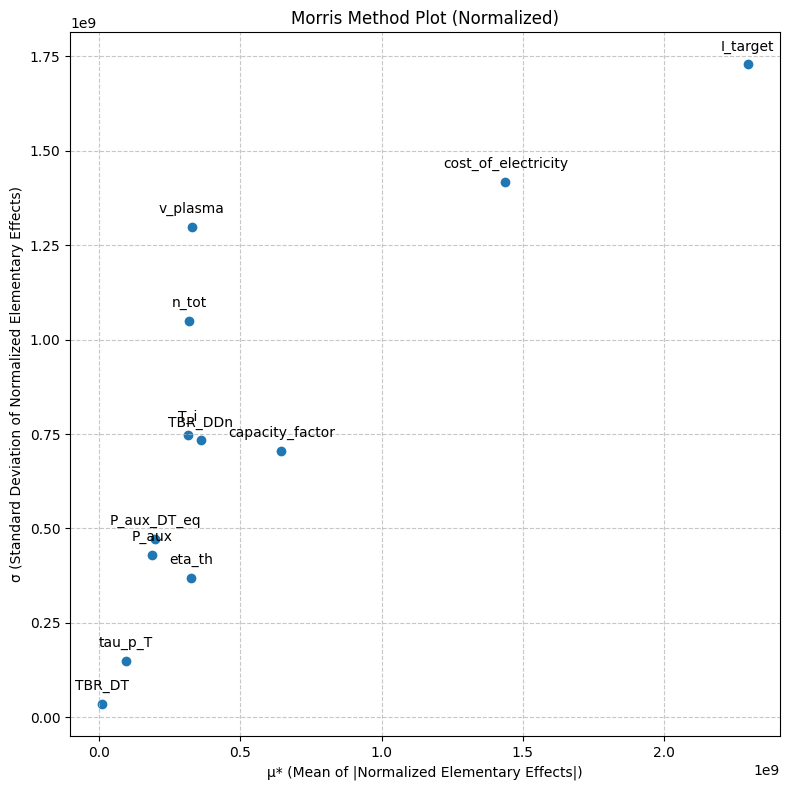


Parameter Sensitivity Ranking:
----------------------------------------
1. I_target: 2.296204e+09 ± 1.091296e+08 (95% CI, n=964)
2. cost_of_electricity: 1.438125e+09 ± 8.796734e+07 (95% CI, n=998)
3. capacity_factor: 6.446495e+08 ± 4.371868e+07 (95% CI, n=998)
4. TBR_DDn: 3.594119e+08 ± 4.561485e+07 (95% CI, n=992)
5. v_plasma: 3.270177e+08 ± 1.003061e+08 (95% CI, n=643)
6. eta_th: 3.242682e+08 ± 2.287606e+07 (95% CI, n=998)
7. n_tot: 3.187035e+08 ± 6.721974e+07 (95% CI, n=935)
8. T_i: 3.139152e+08 ± 4.730406e+07 (95% CI, n=958)
9. P_aux_DT_eq: 1.976879e+08 ± 2.930345e+07 (95% CI, n=998)
10. P_aux: 1.877607e+08 ± 2.664621e+07 (95% CI, n=998)
11. tau_p_T: 9.535707e+07 ± 9.327096e+06 (95% CI, n=997)
12. TBR_DT: 1.104746e+07 ± 2.151569e+06 (95% CI, n=998)


{'startup_time': {'mu': {'v_plasma': np.float64(-199380249.60170388),
   'T_i': np.float64(-131222170.68372679),
   'n_tot': np.float64(-196905594.59440696),
   'tau_p_T': np.float64(-9719035.044745531),
   'P_aux': np.float64(0.0),
   'P_aux_DT_eq': np.float64(0.0),
   'TBR_DT': np.float64(-612216.0755515599),
   'TBR_DDn': np.float64(-42860091.96672745),
   'I_target': np.float64(221909545.30183658),
   'eta_th': np.float64(0.0),
   'capacity_factor': np.float64(0.0),
   'cost_of_electricity': np.float64(0.0)},
  'mu_star': {'v_plasma': np.float64(234737964.12930536),
   'T_i': np.float64(147966727.34229323),
   'n_tot': np.float64(215558172.59100053),
   'tau_p_T': np.float64(10235798.218156865),
   'P_aux': np.float64(0.0),
   'P_aux_DT_eq': np.float64(0.0),
   'TBR_DT': np.float64(777193.6614673807),
   'TBR_DDn': np.float64(45437264.89860223),
   'I_target': np.float64(221909545.30183658),
   'eta_th': np.float64(0.0),
   'capacity_factor': np.float64(0.0),
   'cost_of_electricit

In [110]:
# Run the Elementary Effects analysis
def analyze_model_sensitivity(normalize=True):
    # Set number of trajectories - more is better but costs more computationally
    num_trajectories = 1000
    
    # Run the analysis for startup time
    results_startup = run_elementary_effects(
        solve_for_sample=lump_model,
        parameter_ranges=parameter_ranges_lump,
        num_trajectories=num_trajectories,
        output_metric='startup_time',
        normalize=normalize
    )
    
    # Analyze effect on unrealized gain (profit loss)
    results_gain = run_elementary_effects(
        solve_for_sample=lump_model,
        parameter_ranges=parameter_ranges_lump,
        num_trajectories=num_trajectories,
        output_metric='unrealized_gain',
        normalize=normalize
    )
    
    return {
        'startup_time': results_startup,
        'unrealized_gain': results_gain
    }

# Execute the analysis with normalization
analyze_model_sensitivity(normalize=True)